## Colab Environment Setup

In [1]:
# ===============================
# Cell 1: Colab Environment Setup
# ===============================

import os
import random
import numpy as np

# ML
import xgboost as xgb

# -------------------------------
# Reproducibility
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -------------------------------
# Working directory (Colab)
# -------------------------------
PROJECT_ROOT = "/content"
os.chdir(PROJECT_ROOT)

print("Working directory:", os.getcwd())

# -------------------------------
# Expected files
# -------------------------------
EXPECTED_FILES = [
    "output.fasta",
    "xgboost_1.model",
    "xgboost_2.model"
]

print("\nChecking uploaded files:")
for f in EXPECTED_FILES:
    print(f"{f} →", "FOUND ✅" if os.path.exists(f) else "❌ NOT FOUND")

print("\nFiles currently in /content:")
for f in os.listdir("."):
    print(" -", f)

print("\nCell 1 completed successfully ✅")


Working directory: /content

Checking uploaded files:
output.fasta → FOUND ✅
xgboost_1.model → FOUND ✅
xgboost_2.model → FOUND ✅

Files currently in /content:
 - .config
 - output.fasta
 - predictor.py
 - stability_converter.py
 - xgboost_1.model
 - xgboost_2.model
 - sample_data

Cell 1 completed successfully ✅


## Load Pretrained XGBoost Models

In [2]:
!pip uninstall -y xgboost
!pip install xgboost==1.5.2


Found existing installation: xgboost 3.1.3
Uninstalling xgboost-3.1.3:
  Successfully uninstalled xgboost-3.1.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.6/173.6 MB 7.2 MB/s eta 0:00:00


In [1]:
# ===============================
# Cell 2: Load XGBoost Models
# ===============================

import xgboost as xgb

# -------------------------------
# Load model 1
# -------------------------------
model_1 = xgb.Booster()
model_1.load_model("xgboost_1.model")

# -------------------------------
# Load model 2
# -------------------------------
model_2 = xgb.Booster()
model_2.load_model("xgboost_2.model")

print("✅ Both XGBoost models loaded successfully")

# -------------------------------
# Sanity checks
# -------------------------------
print("Model 1 number of trees:", len(model_1.get_dump()))
print("Model 2 number of trees:", len(model_2.get_dump()))


✅ Both XGBoost models loaded successfully
Model 1 number of trees: 200
Model 2 number of trees: 100


## Load & Parse FASTA Test Dataset

In [2]:
# ===============================
# Cell 3: Load & Parse FASTA
# ===============================

from typing import List, Tuple

FASTA_FILE = "output.fasta"

def read_fasta(file_path: str) -> List[Tuple[str, str]]:
    """
    Reads a FASTA file and returns a list of (header, sequence)
    """
    sequences = []
    header = None
    seq_lines = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    sequences.append((header, "".join(seq_lines)))
                header = line[1:]  # remove '>'
                seq_lines = []
            else:
                seq_lines.append(line)

        # Add last entry
        if header is not None:
            sequences.append((header, "".join(seq_lines)))

    return sequences


# -------------------------------
# Read FASTA
# -------------------------------
fasta_data = read_fasta(FASTA_FILE)

print(f"Total sequences loaded: {len(fasta_data)}")

# -------------------------------
# Preview first 3 sequences
# -------------------------------
for i, (header, seq) in enumerate(fasta_data[:3]):
    print(f"\nSequence {i+1}")
    print("Header:", header)
    print("Length:", len(seq))
    print("Sequence (first 60):", seq[:60] + ("..." if len(seq) > 60 else ""))


Total sequences loaded: 9026

Sequence 1
Header: ECK120016719 AHPFP FORWARD 639002 SIGMA24 STRONG
Length: 81
Sequence (first 60): TAGATGTCCTTGATTAACACCAAAATTAAACCTTTTAAAAACCAGGCATTCAAAAACGGC...

Sequence 2
Header: ECK120009966 BACAP REVERSE 3204175 SIGMA24 STRONG
Length: 81
Sequence (first 60): AAAGAAAATAATTAATTTTACAGCTGTTAAACCAAACGGTTATAACCTGGTCATACGCAG...

Sequence 3
Header: ECK120010006 BAMAP FORWARD 197821 SIGMA24 STRONG
Length: 81
Sequence (first 60): CTGCTGTTCCTTGCGATCGAAAAGATCAAGGGCGGACCGGTATCCGAGCGGGTTCAAGAC...


## Feature Extraction

In [3]:
# ===============================
# Cell 4: Stability Feature Extraction
# ===============================

import numpy as np

# Dinucleotide stability values
stability_values = {
    'AA': -1,
    'AT': -0.88,
    'TA': -0.58,
    'AG': -1.3,
    'GA': -1.3,
    'TT': -1,
    'AC': -1.45,
    'CA': -1.45,
    'TG': -1.44,
    'GT': -1.44,
    'TC': -1.28,
    'CT': -1.28,
    'CC': -1.84,
    'CG': -2.24,
    'GC': -2.27,
    'GG': -1.84
}

def fasta_to_stability_features(fasta_data, window_len=80):
    """
    Converts FASTA sequences into 79 stability features
    """
    feature_matrix = []
    ids = []

    for header, seq in fasta_data:
        seq = seq.upper()

        if len(seq) < window_len:
            continue  # skip short sequences

        # Take last 80 bp
        seq_window = seq[-window_len:]

        # Compute dinucleotide stability values (79)
        features = [
            stability_values.get(seq_window[i:i+2], 0)
            for i in range(len(seq_window) - 1)
        ]

        feature_matrix.append(features)
        ids.append(header)

    return np.array(feature_matrix), ids


# -------------------------------
# Generate feature matrix
# -------------------------------
X_test, seq_ids = fasta_to_stability_features(fasta_data)

print("Feature matrix shape:", X_test.shape)
print("Example feature vector (first 5 values):", X_test[0][:5])


Feature matrix shape: (9026, 79)
Example feature vector (first 5 values): [-1.3  -1.3  -0.88 -1.44 -1.44]


## Run Predictions

In [4]:
# ===============================
# Cell 5: XGBoost Predictions
# ===============================

import xgboost as xgb
import numpy as np
import pandas as pd

# -------------------------------
# Create DMatrix
# -------------------------------
dtest = xgb.DMatrix(X_test)

# -------------------------------
# Predict probabilities
# -------------------------------
proba_1 = model_1.predict(dtest)
proba_2 = model_2.predict(dtest)

# -------------------------------
# Binary predictions (threshold = 0.5)
# -------------------------------
pred_1 = (proba_1 >= 0.5).astype(int)
pred_2 = (proba_2 >= 0.5).astype(int)

# -------------------------------
# Build results DataFrame
# -------------------------------
results_df = pd.DataFrame({
    "sequence_id": seq_ids,
    "xgb1_probability": proba_1,
    "xgb2_probability": proba_2,
    "xgb1_prediction": pred_1,
    "xgb2_prediction": pred_2
})

print("Predictions completed ✅")
results_df.head()


Predictions completed ✅


,sequence_id,xgb1_probability,xgb2_probability,xgb1_prediction,xgb2_prediction
0,ECK120016719 AHPFP FORWARD 639002 SIGMA24 STRONG,0.124337,0.114166,0,0
1,ECK120009966 BACAP REVERSE 3204175 SIGMA24 STRONG,0.324046,0.411893,0,0
2,ECK120010006 BAMAP FORWARD 197821 SIGMA24 STRONG,0.020114,0.034554,0,0
3,ECK120016583 BAMAP2 FORWARD 197026 SIGMA24 STRONG,0.688927,0.963208,1,1
4,ECK120016567 BAMBP REVERSE 2638975 SIGMA24 STRONG,0.508051,0.233834,1,0


In [5]:
# ===============================
# Cell 6: Final Filtering & Save
# ===============================

import pandas as pd
import numpy as np

# -------------------------------
# Apply OR logic (as in training pipeline)
# -------------------------------
results_df["final_prediction"] = (
    (results_df["xgb1_prediction"] == 1) |
    (results_df["xgb2_prediction"] == 1)
).astype(int)

# -------------------------------
# Final confidence score
# (maximum probability between models)
# -------------------------------
results_df["final_confidence"] = results_df[
    ["xgb1_probability", "xgb2_probability"]
].max(axis=1)

# -------------------------------
# Filter predicted promoters
# -------------------------------
predicted_promoters = results_df[
    results_df["final_prediction"] == 1
].copy()

print("Total sequences:", len(results_df))
print("Predicted promoters:", len(predicted_promoters))

# -------------------------------
# Save outputs
# -------------------------------
ALL_RESULTS_FILE = "xgboost_predictions_all.csv"
FILTERED_RESULTS_FILE = "xgboost_predicted_promoters.csv"

results_df.to_csv(ALL_RESULTS_FILE, index=False)
predicted_promoters.to_csv(FILTERED_RESULTS_FILE, index=False)

print("Saved:")
print(" -", ALL_RESULTS_FILE)
print(" -", FILTERED_RESULTS_FILE)

predicted_promoters.head()


Total sequences: 9026
Predicted promoters: 4199
Saved:
 - xgboost_predictions_all.csv
 - xgboost_predicted_promoters.csv


,sequence_id,xgb1_probability,xgb2_probability,xgb1_prediction,xgb2_prediction,final_prediction,final_confidence
3,ECK120016583 BAMAP2 FORWARD 197026 SIGMA24 STRONG,0.688927,0.963208,1,1,1,0.963208
4,ECK120016567 BAMBP REVERSE 2638975 SIGMA24 STRONG,0.508051,0.233834,1,0,1,0.508051
7,ECK120016572 BAMDP2 FORWARD 2735961 SIGMA24 ST...,0.257012,0.721957,0,1,1,0.721957
9,ECK120016566 BEPAP1 FORWARD 2616068 SIGMA24 ST...,0.425032,0.552416,0,1,1,0.552416
10,ECK125135037 BHSAP FORWARD 1169033 SIGMA24 STRONG,0.969803,0.766751,1,1,1,0.969803


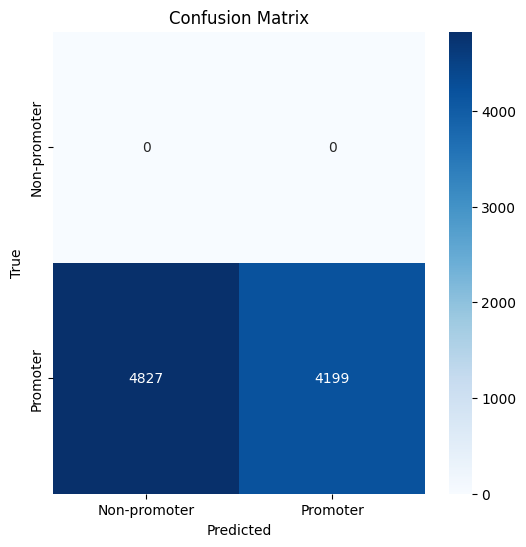

Confusion Matrix:
[[   0    0]
 [4827 4199]]


In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have true labels and predicted labels
# Let's mock these labels (replace with your actual data)
# 1 = Promoter, 0 = Non-promoter
true_labels = [1] * len(pred_1)   # Replace with your actual true labels column
predicted_labels = results_df["final_prediction"]  # Replace with your predicted labels column

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-promoter", "Promoter"], yticklabels=["Non-promoter", "Promoter"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Optionally, print the confusion matrix
print("Confusion Matrix:")
print(cm)


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate the evaluation metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

# Display the evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

# Optionally, you can also get a detailed classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Non-promoter", "Promoter"]))


Accuracy: 0.46521161090183916
Precision: 1.0
Recall: 0.46521161090183916
F1-Score: 0.6350094517958412

Classification Report:
              precision    recall  f1-score   support

Non-promoter       0.00      0.00      0.00         0
    Promoter       1.00      0.47      0.64      9026

    accuracy                           0.47      9026
   macro avg       0.50      0.23      0.32      9026
weighted avg       1.00      0.47      0.64      9026



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reported metrics from the paper
paper_metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [0.85, 0.87, 0.83, 0.85],
    'Source': 'Paper Reported'
}

# Calculated metrics from the independent dataset
# These variables (accuracy, precision, recall, f1) are already available from previous cells.
independent_metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy, precision, recall, f1],
    'Source': 'Independent Dataset'
}

# Create DataFrames
df_paper = pd.DataFrame(paper_metrics)
df_independent = pd.DataFrame(independent_metrics)

# Concatenate DataFrames
df_combined = pd.concat([df_paper, df_independent])

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Source', data=df_combined, palette='viridis')
plt.title('Comparison of Model Performance Metrics: Paper vs. Independent Dataset')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(title='Source')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('image.png') # Save the plot as image.png
plt.close() # Close the plot to free memory, as it's saved

print("Comparison plot generated successfully and saved as image.png.")

Comparison plot generated successfully and saved as image.png.
